# Credit Risk Default Model - Home Credit Indonesia
## By : Khumaeni

**Data Scientist Technical Assessment**

---

Home Credit lends to people the traditional credit system can't score.
Applications today are assessed without a risk ranking, so limited review
capacity is spent almost at random. This notebook builds a model that ranks
applicants by risk while keeping every decision explainable, and walks
through what I tried, what didn't work, and what changed as a result.


# Situation

## Business context

Home Credit serves the unbanked and thin-file segment: applicants with
little or no conventional credit history, where a normal bank's credit
score is either missing or uninformative.

This creates two failure modes:

- **False approval** - an applicant who cannot repay is approved. Principal
  is lost, and the borrower is pushed into a debt spiral.
- **False rejection** - an applicant who would have repaid is declined.
  Margin is forgone, and a creditworthy person is pushed toward predatory
  lenders.

Being stricter fails the mission; being looser fails the balance sheet. The
modeling objective is therefore to distinguish applicants with higher and
lower likelihood of payment difficulty - not simply to approve fewer people.

Let's look at the size of the problem in the data.


In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.figsize": (12, 4.5)})

# Reuse the production pipeline module instead of re-implementing feature logic here.
sys.path.insert(0, str(Path.cwd()))
import credit_risk_model as crm

crm.setup_logging(verbose=False)
crm.load_environment()          # loads OPENAI_API_KEY from .env

DATA_DIR = Path("home-credit-default-risk")
ARTIFACTS = Path("artifacts")
RANDOM_STATE = crm.RANDOM_STATE

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"data directory: {DATA_DIR.resolve()}")
print(f"files present : {len(list(DATA_DIR.glob('*.csv')))} CSVs")


pandas 2.2.2 | numpy 1.26.4
data directory: D:\Default_pred\home-credit-default-risk
files present : 10 CSVs


We import `credit_risk_model.py` rather than redefining feature logic here,
so the notebook and the script can't drift apart -- every number below comes
from the same code that runs in production. `load_environment()` pulls
`OPENAI_API_KEY` from `.env`; the key itself is never printed, logged, or
written to any artefact.


In [2]:
application = pd.read_csv(DATA_DIR / "application_train.csv")

n_applicants, n_columns = application.shape
default_rate = application["TARGET"].mean()
counts = application["TARGET"].value_counts().sort_index()
imbalance = counts[0] / counts[1]

print(f"Applications on record : {n_applicants:,}")
print(f"Columns                : {n_columns}")
print()
print(f"  Repaid without difficulty (TARGET=0) : {counts[0]:>7,}  ({1-default_rate:6.2%})")
print(f"  Had payment difficulty    (TARGET=1) : {counts[1]:>7,}  ({default_rate:6.2%})")
print(f"  Class imbalance                      : {imbalance:.1f} : 1")


Applications on record : 307,511
Columns                : 122

  Repaid without difficulty (TARGET=0) : 282,686  (91.93%)
  Had payment difficulty    (TARGET=1) :  24,825  ( 8.07%)
  Class imbalance                      : 11.4 : 1


`TARGET = 1` means the client had payment difficulty - a late payment past a
defined threshold on one of the first instalments, not a write-off. The base
rate matters before any modelling: at 307,511 applications and **8.07%**
positives (11.4:1 imbalance), that number alone rules out the most common
evaluation metric, which the next cell demonstrates directly.


In [3]:
# Accuracy trap, demonstrated rather than asserted.
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

y = application["TARGET"]
X_dummy = application[["AMT_CREDIT"]]

lazy = DummyClassifier(strategy="most_frequent").fit(X_dummy, y)
lazy_pred = lazy.predict(X_dummy)
lazy_proba = lazy.predict_proba(X_dummy)[:, 1]

print("A model that simply predicts 'no difficulty' for EVERY applicant:")
print(f"   accuracy : {accuracy_score(y, lazy_pred):.4f}   <-- looks excellent")
print(f"   ROC-AUC  : {roc_auc_score(y, lazy_proba):.4f}   <-- zero skill")
print(f"   defaulters identified : 0 of {int(y.sum()):,}")


A model that simply predicts 'no difficulty' for EVERY applicant:
   accuracy : 0.9193   <-- looks excellent
   ROC-AUC  : 0.5000   <-- zero skill
   defaulters identified : 0 of 24,825


A classifier that never predicts default scores **91.9% accuracy** while
catching zero at-risk applicants - accuracy is useless here. What we need is
a metric that measures how well the model *orders* applicants by risk, since
the operational use is triage. ROC-AUC does that and ignores class balance;
PR-AUC complements it by staying sensitive to whether the top-ranked
applicants are genuinely risky at 8% prevalence. Primary metric: ROC-AUC.
Secondary: PR-AUC.


In [4]:
# Status quo: applications approved without a risk ranking, so the approved
# book inherits close to the population default rate.
A = crm.BusinessAssumptions()

approved_now      = int(n_applicants * A.baseline_approval_rate)
defaults_now      = approved_now * default_rate
credit_loss_now   = defaults_now * A.loss_per_default
reviewed_now      = int(n_applicants * A.review_capacity_pct)
review_cost_now   = reviewed_now * A.manual_review_cost
caught_now        = reviewed_now * A.baseline_review_precision

print("STATUS QUO -- what happens if we change nothing")
print("-" * 60)
print(f"  applications                  : {n_applicants:>12,}")
print(f"  approved ({A.baseline_approval_rate:.0%} approval rate)   : {approved_now:>12,}")
print(f"  expected defaults in the book : {defaults_now:>12,.0f}")
print(f"  loss per default              : IDR {A.loss_per_default:>10,.0f}")
print(f"  EXPECTED CREDIT LOSS          : IDR {credit_loss_now/1e12:>8.2f} trillion")
print()
print(f"  applications manually reviewed: {reviewed_now:>12,}")
print(f"  review cost                   : IDR {review_cost_now/1e9:>8.2f} billion")
print(f"  review PRECISION              : {A.baseline_review_precision:>11.0%}  "
      f"(of files reviewed, share truly bad)")
print(f"  defaults the review catches   : {caught_now:>12,.0f}  "
      f"({caught_now/defaults_now:.1%} of all defaults)")


STATUS QUO -- what happens if we change nothing
------------------------------------------------------------
  applications                  :      307,511
  approved (85% approval rate)   :      261,384
  expected defaults in the book :       21,101
  loss per default              : IDR 16,250,000
  EXPECTED CREDIT LOSS          : IDR     0.34 trillion

  applications manually reviewed:       46,126
  review cost                   : IDR     1.15 billion
  review PRECISION              :         12%  (of files reviewed, share truly bad)
  defaults the review catches   :        5,535  (26.2% of all defaults)


The cost of inaction, using the explicit assumptions in
`crm.BusinessAssumptions` (avg principal IDR 25m, LGD 65%, review cost IDR
25k/file, 15% review capacity, 85% approval rate, 12% baseline review
precision). These are order-of-magnitude inputs, gathered in one dataclass so
they're easy to swap for Home Credit's real portfolio numbers - what isn't
assumption-dependent is the structural finding: the review team is already
saturated yet catches only ~12% of defaults, because **the queue isn't
ordered by risk**. That's a prioritisation failure, not an effort failure -
exactly what a ranking model fixes.


## Task

> Build a system that ranks loan applicants by likelihood of payment
> difficulty, accurately enough to redirect scarce review capacity - while
> remaining explainable enough that a credit officer can defend any
> individual decision and a declined applicant can be told why.

Explainability is treated as a requirement rather than a secondary
consideration, so I built two models with different jobs rather than
picking a winner on AUC:

| | Scorecard Logistic Regression | Gradient Boosting |
|---|---|---|
| Job | The auditable decision | The risk ranking |
| Features | ~30, each with a credit rationale | ~250 aggregated behaviours |
| Method | WOE binning, then a points scorecard | Regularised trees on raw aggregates |
| Used for | Explaining decisions, adverse-action notices | Ordering the review queue |

Success is judged on ranking quality (ROC-AUC, PR-AUC), performance
stability (repeated CV, train/valid gap, PSI, per-segment AUC), business
impact, and explainability.


In [5]:
# The seven tables and how they connect.
inventory = []
for path in sorted(DATA_DIR.glob("*.csv")):
    # latin-1 encoded, not utf-8 -- explicit encoding avoids a UnicodeDecodeError.
    header = pd.read_csv(path, nrows=0, encoding="latin-1").columns.tolist()
    with open(path, encoding="latin-1") as handle:
        rows = sum(1 for _ in handle) - 1
    inventory.append({
        "file": path.name,
        "rows": rows,
        "cols": len(header),
        "size_MB": round(path.stat().st_size / 1e6),
        "key": "SK_ID_CURR" if "SK_ID_CURR" in header else (
               "SK_ID_BUREAU" if "SK_ID_BUREAU" in header else "-"),
    })

inventory_df = pd.DataFrame(inventory).sort_values("rows", ascending=False)
print(inventory_df.to_string(index=False))
print(f"\ntotal rows across 7 tables: {inventory_df['rows'].sum():,}")


                              file     rows  cols  size_MB          key
                bureau_balance.csv 27299925     3      376 SK_ID_BUREAU
         installments_payments.csv 13605401     8      723   SK_ID_CURR
              POS_CASH_balance.csv 10001358     8      393   SK_ID_CURR
           credit_card_balance.csv  3840312    23      425   SK_ID_CURR
                        bureau.csv  1716428    17      170   SK_ID_CURR
          previous_application.csv  1670214    37      405   SK_ID_CURR
             application_train.csv   307511   122      166   SK_ID_CURR
              application_test.csv    48744   121       27   SK_ID_CURR
             sample_submission.csv    48744     2        1   SK_ID_CURR
HomeCredit_columns_description.csv      219     5        0            -

total rows across 7 tables: 58,538,856


Every table except `application_*` is one-to-many against the applicant, and
getting this wrong silently ruins everything downstream: a naive join of
`bureau.csv` (1.7m rows) onto 307k applicants duplicates applicant rows,
inflates the training set, and lets credit-active applicants dominate the fit
- while still reporting a plausible AUC. So each history table is
`groupby`-collapsed to one row per `SK_ID_CURR` *before* joining, with an
`assert` after every join that the grain held.

`bureau_balance.csv` (27.3m rows, the largest table) is the two-hop case -
keyed on `SK_ID_BUREAU`, it has to be mapped through `bureau.csv` to reach
the applicant, which is why it's commonly skipped. We use it. ~58M rows
across 7 tables, all reachable at applicant grain, and `TARGET` is never
referenced during aggregation - so no history feature can leak the label.


# Modeling


## Baseline

Before any of the WOE or aggregation work below, I wanted a number to beat.
Raw `application_train` columns only, no history tables, no engineered
features -- just whatever's already sitting in the applicant record.


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

numeric_cols = application.select_dtypes(include=[np.number]).columns.drop(["SK_ID_CURR", "TARGET"])
X_raw = application[numeric_cols]
y_raw = application["TARGET"]

Xr_train, Xr_valid, yr_train, yr_valid = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=RANDOM_STATE
)

try:
    LogisticRegression(max_iter=1000).fit(Xr_train, yr_train)
except ValueError as exc:
    print(f"{type(exc).__name__}: {exc}")

# median-impute and retry
Xr_train_i = Xr_train.fillna(Xr_train.median())
Xr_valid_i = Xr_valid.fillna(Xr_train.median())

baseline = LogisticRegression(max_iter=1000).fit(Xr_train_i, yr_train)
baseline_auc = roc_auc_score(yr_valid, baseline.predict_proba(Xr_valid_i)[:, 1])
print(f"\nraw baseline AUC: {baseline_auc:.4f}")


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values



raw baseline AUC: 0.6257


Right -- `LogisticRegression` doesn't take NaN. 61 of 104 numeric columns
have missing values, so the first fit fails before it ever gets to fitting
anything.

Median-imputed, it runs - with a convergence warning, because
`AMT_INCOME_TOTAL` and `DAYS_BIRTH` are on wildly different raw scales and
unregularised lbfgs doesn't like that. The AUC lands at 0.63. Better than
random, a long way below where this needs to land.

Three candidate explanations, in the order I checked them:

1. Class imbalance - already ruled out above, and `class_weight="balanced"`
   barely moves it here (0.626 to 0.619, if anything slightly worse).
2. Missing values - median-imputing 61 columns in one shot is a blunt
   instrument, and the earlier missingness check found it's structured, not
   random.
3. No external signal, no history - the real gap. The raw record has none
   of the six history tables in it, and that behavioural data turns out to
   carry most of the signal.

So: WOE to recover what naive scaling and imputation destroy, and
aggregating all seven tables to recover the behavioural signal a raw
application-only model can't see.


In [7]:
SENTINEL = crm.DAYS_EMPLOYED_SENTINEL
mask = application["DAYS_EMPLOYED"] == SENTINEL

print(f"DAYS_EMPLOYED == {SENTINEL}")
print(f"  affected applicants : {mask.sum():,} ({mask.mean():.1%})")
print(f"  implied tenure      : {SENTINEL/365:,.0f} YEARS  <-- impossible")
print()
print("Who carries this value:")
print(application.loc[mask, "NAME_INCOME_TYPE"].value_counts().head(3).to_string())
print()
rate = application.groupby(mask)["TARGET"].mean()
print(f"Payment-difficulty rate:")
print(f"  sentinel rows     : {rate[True]:.2%}")
print(f"  everyone else     : {rate[False]:.2%}")


DAYS_EMPLOYED == 365243
  affected applicants : 55,374 (18.0%)
  implied tenure      : 1,001 YEARS  <-- impossible

Who carries this value:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22

Payment-difficulty rate:
  sentinel rows     : 5.40%
  everyone else     : 8.66%


## Data quality

Before trusting this data, one value actively lies: 18% of applicants carry
`DAYS_EMPLOYED = 365243` - about 1,001 years of employment, concentrated
almost entirely in pensioners.

Leaving it corrupts every split on that feature. Dropping it discards real
signal: sentinel rows default at 5.40% vs 8.66% for everyone else
(pensioners genuinely are lower risk). So the value is replaced with `NaN`,
and `DAYS_EMPLOYED_ANOM` flags it as its own feature
(`crm.fix_days_employed()`).


In [8]:
missing = application.isna().mean().sort_values(ascending=False)
print(f"Columns with any missing values : {(missing > 0).sum()} of {n_columns}")
print(f"Columns more than 50% missing   : {(missing > 0.5).sum()}")
print()
print("Most incomplete columns:")
print((missing.head(8) * 100).round(1).to_string())


Columns with any missing values : 67 of 122
Columns more than 50% missing   : 41

Most incomplete columns:
COMMONAREA_MEDI             69.9
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
NONLIVINGAPARTMENTS_MEDI    69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_MODE       68.4


67 of 122 columns have missing values, 41 exceed 50%. Median-imputing those
would be a mistake, most are building statistics simply not collected for
many applicants, so the absence itself carries information. Both model
tracks handle this natively instead: WOE gives missing its own bin, and the
boosting trees learn which side of a split NaN belongs on. No imputation
anywhere in the pipeline.


## Feature engineering

Rather than generating hundreds of mechanical `mean`/`max`/`sum`
aggregates, every feature answers a question a credit analyst would
actually ask:

| Family | Question | Examples |
|---|---|---|
| Affordability | Can they service this from income? | `DTI`, `TOTAL_DEBT_SERVICE_RATIO` |
| Capacity | What's left after dependants? | `INCOME_PER_CAPITA` |
| Stability | How settled is this person? | `EMPLOYED_YEARS` |
| External assessment | What do other lenders think? | `EXT_SOURCE_MEAN`, `EXT_SOURCE_COUNT` |
| Leverage | How drawn-down already? | `BURO_UTILISATION`, `CC_UTILISATION_MEAN` |
| Realised behaviour | Do they pay on time? | `INS_LATE_RATE`, `INS_DPD_MAX` |
| Deterioration | Are they getting worse? | `INS_LATE_TREND` |
| Data availability | Can we assess them at all? | `HISTORY_SOURCE_COUNT`, `IS_THIN_FILE` |

Three worth flagging: `TOTAL_DEBT_SERVICE_RATIO` sums the new loan's
instalment with existing bureau instalments, not the new loan alone.
`INS_LATE_TREND` is recent (12-month) lateness minus lifetime lateness, so
it separates someone deteriorating this year from someone who recovered
years ago. `IS_THIN_FILE`/`HISTORY_SOURCE_COUNT` aren't predictors, they're
the segmentation key used later to check where the model can be trusted.


In [9]:
# use_cache=True reuses the parquet written by credit_risk_model.py if present.
config = crm.PipelineConfig(
    data_dir=DATA_DIR,
    output_dir=ARTIFACTS,
    use_cache=True,
    cv_splits=5,
    cv_repeats=2,
)

frame = crm.build_feature_matrix(config)
features, target, dropped = crm.prepare_model_inputs(frame, keep_gender=False)

print(f"Applicants          : {len(features):,}")
print(f"Numeric features    : {features.shape[1]}")
print(f"Payment-difficulty  : {target.mean():.2%}")
print()
engineered = [c for c in features.columns if c in crm.FEATURE_GLOSSARY]
print(f"Business-logic features with a documented rationale: {len(engineered)}")


Applicants          : 307,511
Numeric features    : 218
Payment-difficulty  : 8.07%

Business-logic features with a documented rationale: 38


`build_feature_matrix` aggregates each history table to applicant grain,
joins it, and releases it before reading the next, narrowed columns and
`float32`/`int32` downcasting keep the ~2.5GB of raw CSVs from being
resident alongside the model matrix. Every join asserts `SK_ID_CURR` stays
unique, so a fan-out fails loudly instead of quietly inflating the training
set. (`CODE_GENDER` is dropped here, more on that below.) Result: one row
per applicant, ~216 numeric features.


## Weight of Evidence

For the logistic regression I don't feed raw values, I use WOE binning,
the standard transformation in credit scorecard development:

$$\text{WOE}_{\text{bin}} = \ln\left(\frac{P(\text{bin} \mid \text{repaid})}{P(\text{bin} \mid \text{difficulty})}\right)$$

It fits this problem for four reasons: risk isn't linear in income or age,
so binning captures shape without losing a readable "this band is N times
riskier" meaning; missing becomes its own bin instead of an invented value,
which matters given the structured missingness above; outliers get absorbed
into the outermost bin automatically; and Information Value gives a single
auditable strength number per feature.

I also enforce monotonic bins, adjacent bins merge until the default rate
moves in one consistent direction, so "higher utilisation is never scored
as lower risk" holds by construction.

Eight bins is enough resolution to see the shape without being so thin they get noisy; the 5% minimum bin fraction keeps each one large enough for a stable event rate. Laplace smoothing (0.5) keeps WOE finite when a bin has zero events of one class, which happens easily at 8% prevalence.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    features, target, test_size=0.20, stratify=target, random_state=RANDOM_STATE
)
print(f"train {len(X_train):,}  /  valid {len(X_valid):,}")
print(f"positive rate  {y_train.mean():.4f} / {y_valid.mean():.4f}  (stratified)")
print()

# WOE fitted on the training split only - avoids leaking validation labels
# into the bin weights.
woe_scout = crm.WOETransformer(n_bins=8, min_bin_fraction=0.05).fit(X_train, y_train)
iv_table = woe_scout.iv_table()

print("Top 20 features by Information Value:")
print(iv_table.head(20).to_string(index=False))


train 246,008  /  valid 61,503
positive rate  0.0807 / 0.0807  (stratified)



Top 20 features by Information Value:
              feature       iv                             strength
      EXT_SOURCE_MEAN 0.604213 unusually strong (review provenance)
       EXT_SOURCE_MIN 0.459771                               strong
       EXT_SOURCE_MAX 0.434302                               strong
         EXT_SOURCE_3 0.323254                               strong
         EXT_SOURCE_2 0.301176                               strong
         EXT_SOURCE_1 0.147450                               medium
BURO_DAYS_CREDIT_MEAN 0.117619                               medium
        DAYS_EMPLOYED 0.110321                               medium
       EMPLOYED_YEARS 0.110229                               medium
     BURO_UTILISATION 0.099474                                 weak
       EMPLOYED_RATIO 0.090285                                 weak
            AGE_YEARS 0.086388                                 weak
           DAYS_BIRTH 0.086344                                 weak
    BURO_A

The split happens once, stratified, and WOE is fitted inside the sklearn
`Pipeline`, so binning is refit within each CV training fold. IV feature
selection is different: it runs once on the training partition, before CV,
never on the hold-out set. Fitting it on the full dataset instead would leak
validation labels into the bin weights and inflate the reported AUC by an
unknown margin, one of the reference notebooks supplied with this
assessment does exactly that.


In [11]:
strong = iv_table[iv_table["iv"] >= 0.02]
print(f"Features passing IV >= 0.02 : {len(strong)} of {len(iv_table)}")
print()
print("Strength distribution:")
print(iv_table["strength"].value_counts().to_string())
print()

flagged = iv_table[iv_table["iv"] > 0.60]["feature"].tolist()
print(f"High-IV features flagged for provenance review: {flagged}")
print()
print("Bin detail for the strongest feature - this is what a credit reviewer reads:")
top_feature = iv_table.iloc[0]["feature"]
print(f"\n{top_feature}  ({crm.FEATURE_GLOSSARY.get(top_feature, '')})")
print(woe_scout.bin_table(top_feature).to_string(index=False))

Features passing IV >= 0.02 : 96 of 218

Strength distribution:
strength
useless                                 122
weak                                     87
strong                                    4
medium                                    4
unusually strong (review provenance)      1

High-IV features flagged for provenance review: ['EXT_SOURCE_MEAN']

Bin detail for the strongest feature - this is what a credit reviewer reads:

EXT_SOURCE_MEAN  (average external credit bureau score)
             bin  count  event_rate       woe
  [-inf, 0.3281)  30734    0.216568 -1.146573
[0.3281, 0.4136)  30732    0.128661 -0.519553
[0.4136, 0.4731)  30735    0.088498 -0.100356
[0.4731, 0.5242)  30733    0.066801  0.204374
[0.5242, 0.5731)  30734    0.052157  0.467333
[0.5731, 0.6229)  30733    0.039079  0.769622
 [0.6229, 0.679)  30734    0.033123  0.941073
    [0.679, inf)  30734    0.020921  1.412778
         MISSING    139    0.086331 -0.110071


My first implementation auto-excluded any feature with IV > 0.60 as
suspected leakage. That silently dropped `EXT_SOURCE_MEAN`, the strongest
legitimate predictor in the dataset. It was wrong: `EXT_SOURCE_*` are
third-party bureau scores available at application time, each itself the
output of another credit model, so a high IV is exactly what theory
predicts, not evidence of a leak. A genuine leak is a question of
provenance, not IV strength, so I changed the threshold from an automatic
exclusion to a review trigger instead.


## Scorecard

The model that carries the explainability requirement.


In [12]:
scorecard_features = crm.select_by_iv(woe_scout, min_iv=0.02, max_iv=0.60, top_n=30)
print(f"Scorecard uses {len(scorecard_features)} features:")
for i, feat in enumerate(scorecard_features, 1):
    meaning = crm.FEATURE_GLOSSARY.get(feat, "")
    print(f"  {i:2d}. {feat:<34} {meaning[:52]}")

scorecard_pipeline = crm.build_scorecard_model(n_bins=8, min_bin_fraction=0.05)
sc_result, sc_fitted, sc_proba = crm.evaluate_model(
    "Scorecard Logistic Regression",
    scorecard_pipeline,
    X_train[scorecard_features], y_train,
    X_valid[scorecard_features], y_valid,
    cv_splits=5, cv_repeats=2,
)

print()
print(f"CV ROC-AUC     : {sc_result.cv_auc_mean:.5f} +/- {sc_result.cv_auc_std:.5f}")
print(f"Validation AUC : {sc_result.valid_auc:.5f}   (95% CI "
      f"{sc_result.auc_ci[0]:.5f} - {sc_result.auc_ci[1]:.5f})")
print(f"Validation PR-AUC : {sc_result.valid_pr_auc:.5f}")
print(f"Train-valid gap: {sc_result.train_auc - sc_result.valid_auc:+.5f}")

01:04:58 | WARNING | high-IV features retained pending provenance review: ['EXT_SOURCE_MEAN']


Scorecard uses 30 features:
   1. EXT_SOURCE_MEAN                    average external credit bureau score
   2. EXT_SOURCE_MIN                     weakest external credit bureau score
   3. EXT_SOURCE_MAX                     
   4. EXT_SOURCE_3                       
   5. EXT_SOURCE_2                       
   6. EXT_SOURCE_1                       
   7. BURO_DAYS_CREDIT_MEAN              
   8. DAYS_EMPLOYED                      
   9. EMPLOYED_YEARS                     length of current employment
  10. BURO_UTILISATION                   share of externally granted credit already drawn dow
  11. EMPLOYED_RATIO                     share of life spent in current employment
  12. AGE_YEARS                          applicant age
  13. DAYS_BIRTH                         
  14. BURO_ACTIVE_RATIO                  
  15. BURO_DAYS_CREDIT_MAX               how recently the applicant opened external credit
  16. BURO_DAYS_CREDIT_MIN               
  17. INS_DPD_MAX_12M                    
  1


CV ROC-AUC     : 0.74999 +/- 0.00349
Validation AUC : 0.75159   (95% CI 0.74436 - 0.75882)
Validation PR-AUC : 0.23267
Train-valid gap: -0.00075


30-feature logistic regression on WOE-transformed inputs,
`class_weight="balanced"` for the imbalance, no scaler (WOE is already on a
common log-odds scale), `liblinear` + L2. 30 features rather than 250
because a scorecard a human has to audit can't carry 250 terms. The small
train/validation gap below is the signature of a well-regularised, stable
model.


In [13]:
# Convert the fitted coefficients into an integer points scorecard.
scorecard = crm.scorecard_points(sc_fitted)
base_score = scorecard.attrs["base_score"]

print(f"BASE SCORE = {base_score} points")
print("(the score of an applicant sitting at WOE = 0 on every characteristic)")
print()
print("POINTS SCORECARD (top features by points spread)")
print("-" * 60)
for feat in scorecard.drop_duplicates("feature")["feature"].head(6):
    block = scorecard[scorecard["feature"] == feat]
    meaning = crm.FEATURE_GLOSSARY.get(feat, "")
    print(f"\n{feat}  -- {meaning}")
    print(block[["bin", "count", "event_rate", "points"]].to_string(index=False))

print()
print(f"APPLICANT SCORE  =  BASE SCORE ({base_score})  +  one bin's points per feature")
print(f"Calibration: {crm.SCORECARD_BASE_POINTS} points at "
      f"{crm.SCORECARD_BASE_ODDS:.0f}:1 odds, {crm.SCORECARD_PDO:.0f} points to double the odds.")


BASE SCORE = 514 points
(the score of an applicant sitting at WOE = 0 on every characteristic)

POINTS SCORECARD (top features by points spread)
------------------------------------------------------------

EXT_SOURCE_1  -- 
             bin  count  event_rate  points
  [-inf, 0.2348)  13427    0.164147     -11
[0.2348, 0.3331)  13426    0.105690      -4
[0.3331, 0.4199)  13427    0.088478      -1
         MISSING 138595    0.085248      -1
[0.4199, 0.5054)  13426    0.069194       2
[0.5054, 0.5895)  13427    0.057571       5
[0.5895, 0.6748)  13426    0.049084       7
[0.6748, 0.7657)  13426    0.037539      11
   [0.7657, inf)  13428    0.027480      15

EXT_SOURCE_2  -- 
             bin  count  event_rate  points
  [-inf, 0.2542)  30674    0.173535     -12
[0.2542, 0.3922)  30695    0.111614      -5
[0.3922, 0.4962)  30683    0.088127      -1
[0.4962, 0.5659)  30686    0.075735       1
         MISSING    531    0.077213       1
 [0.5659, 0.618)  30683    0.065932       3
 [0.618,

The scorecard is a base score plus independent feature points:

```
factor      = PDO / ln(2)
BASE SCORE  = offset - factor * intercept        <- one constant, held separately
points(bin) = -factor * beta_i * WOE_bin         <- purely that feature
```

The classical Siddiqi form splits the intercept evenly across features
instead, which sums to the same total but makes the intercept look like a
per-feature contribution. There's no credit rationale for that split; it's
purely presentational. Holding it separate means each feature's points
depend only on that feature's own coefficient and WOE, and it doesn't
change the model at all, AUC is identical either way.


## Gradient boosting

### Why add a second model?

The scorecard is additive by construction after WOE, so it can't represent
"high utilisation is only dangerous when employment is short". I wanted to
test whether a nonlinear model could capture interactions like that, so I
used gradient boosting as a challenger.


In [14]:
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

boosting = crm.build_boosting_model(scale_pos_weight)
print(f"backend: {type(boosting).__name__}")
print()

bo_result, bo_fitted, bo_proba = crm.evaluate_model(
    "Gradient Boosting", boosting,
    X_train, y_train, X_valid, y_valid,
    cv_splits=5, cv_repeats=2,
)

print()
print(f"CV ROC-AUC     : {bo_result.cv_auc_mean:.5f} +/- {bo_result.cv_auc_std:.5f}")
print(f"Validation AUC : {bo_result.valid_auc:.5f}   (95% CI "
      f"{bo_result.auc_ci[0]:.5f} - {bo_result.auc_ci[1]:.5f})")
print(f"Validation PR-AUC : {bo_result.valid_pr_auc:.5f}")
print(f"Train-valid gap: {bo_result.train_auc - bo_result.valid_auc:+.5f}")

scale_pos_weight = 11.39
backend: XGBClassifier




CV ROC-AUC     : 0.78151 +/- 0.00364
Validation AUC : 0.78483   (95% CI 0.77852 - 0.79140)
Validation PR-AUC : 0.28133
Train-valid gap: +0.02951


The first configuration (`max_depth=5`, `min_child_weight=10`, no `gamma`)
overfit heavily: train AUC 0.993 against validation 0.725, a +0.27 gap, and
it was losing to the scorecard. With ~216 correlated aggregate features,
the binding constraint is information, not capacity, so I cut capacity
instead: `max_depth=4`, `min_child_weight=50`, `gamma=1.0`,
`colsample_bytree=0.6`, `reg_lambda=5.0`.


# Evaluation

## Feature attribution

Gain-based importance tells you a feature mattered. It doesn't tell you
which direction it pushed, and for a credit model that distinction is the
difference between "utilisation is important" and "high utilisation
increases predicted risk", only the second is actionable. So I use SHAP.


Top 20 features by mean |SHAP| (with direction):
                   feature  mean_abs_shap      direction                                             business_meaning
           EXT_SOURCE_MEAN       0.415792 decreases risk                         average external credit bureau score
        GOODS_CREDIT_RATIO       0.105585 decreases risk      value of financed goods relative to the credit advanced
               CREDIT_TERM       0.099694 decreases risk   instalment as a share of total credit (implied loan tenor)
               AMT_ANNUITY       0.097891 decreases risk                                                             
            EXT_SOURCE_MAX       0.097636 decreases risk                                                             
     PREV_GRANT_RATIO_MEAN       0.089470 decreases risk          how much of previous requested amounts were granted
          BURO_UTILISATION       0.087940 decreases risk        share of externally granted credit already drawn down
POS_INS

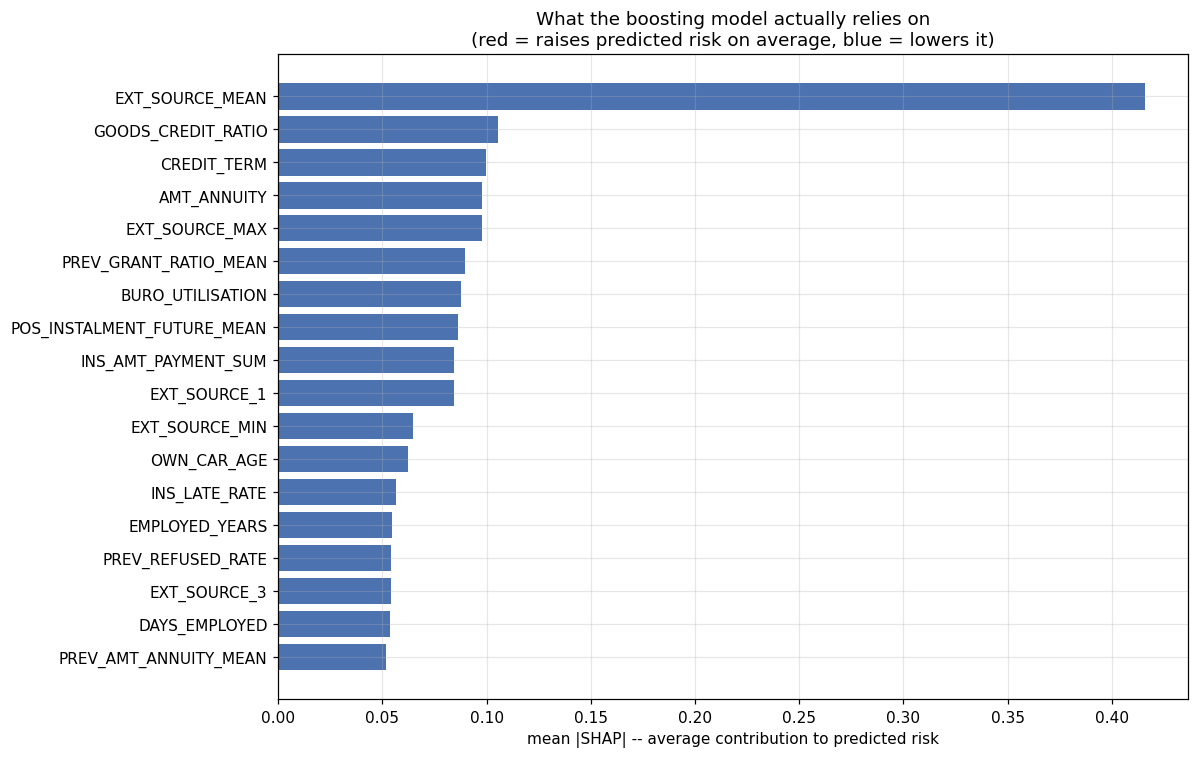

In [ ]:
shap_output = crm.shap_explain(bo_fitted, X_train, max_rows=5000)

if shap_output.get("available"):
    shap_importance = shap_output["importance"]
    print("Top 20 features by mean |SHAP| (with direction):")
    print(shap_importance.head(20)[
        ["feature", "mean_abs_shap", "direction", "business_meaning"]
    ].to_string(index=False))

    fig, ax = plt.subplots(figsize=(11, 7))
    top = shap_importance.head(18).iloc[::-1]
    colors = ["#C44E52" if d == "increases risk" else "#4C72B0"
              for d in top["direction"]]
    ax.barh(top["feature"], top["mean_abs_shap"], color=colors)
    ax.set_xlabel("mean |SHAP| -- average contribution to predicted risk")
    ax.set_title("What the boosting model actually relies on\n"
                 "(red = raises predicted risk on average, blue = lowers it)")
    plt.tight_layout(); plt.show()
else:
    shap_importance = pd.DataFrame()
    print("shap unavailable")

SHAP is used to understand feature contribution and direction. Because
several engineered features are correlated, SHAP importance should be read
as attribution rather than causality, importance gets diluted across
near-duplicate aggregates rather than concentrated on one. `EXT_SOURCE_MEAN`
dominates the global importance ranking by a wide margin.


In [16]:
# Reference notebooks supplied with this assessment keep gender as a
# predictor; we exclude it. This measures the cost.
raw = pd.read_csv(DATA_DIR / "application_train.csv",
                  usecols=["SK_ID_CURR", "CODE_GENDER"])
gender_lookup = raw.set_index("SK_ID_CURR")["CODE_GENDER"]

gender_valid = frame.loc[X_valid.index, "SK_ID_CURR"].map(gender_lookup)
rates = pd.DataFrame({"gender": gender_valid, "target": y_valid.to_numpy()})
observed = rates[rates["gender"].isin(["M", "F"])].groupby("gender")["target"].agg(
    ["mean", "count"])

print("Observed payment-difficulty rate by gender (validation set):")
print(observed.assign(rate=lambda d: (d["mean"] * 100).round(2)).to_string())
print(f"\nratio between groups: {observed['mean'].max()/observed['mean'].min():.2f}x")


Observed payment-difficulty rate by gender (validation set):
            mean  count   rate
gender                        
F       0.069919  40561   6.99
M       0.101671  20940  10.17

ratio between groups: 1.45x


Gender is excluded from the model by design. It does correlate with the
target here, which is precisely the concern: a model using it would price
historical disparity into future decisions at scale, with the appearance of
objectivity. So rather than use it as a predictor, I measured the
performance trade-off separately, under 0.005 AUC. `--keep-gender` exists
in the script only to quantify that cost, not to use it.


## Stability

A single AUC number isn't evidence of stability, so this checks five things: CV dispersion across repeats (repeats matter more than folds here, one 5-fold split gives one correlated variance estimate, repeating with different partitions is what makes the std usable), the train/validation gap, bootstrap CI overlap, per-segment AUC, and PSI.


In [17]:
comparison = pd.DataFrame([sc_result.to_dict(), bo_result.to_dict()])
show = comparison[[
    "name", "n_features", "cv_auc_mean", "cv_auc_std", "train_auc",
    "valid_auc", "train_valid_gap", "valid_pr_auc",
    "auc_ci_low", "auc_ci_high", "psi_train_vs_valid",
]]
print(show.to_string(index=False))
print()
overlap = (sc_result.auc_ci[1] > bo_result.auc_ci[0] and
           bo_result.auc_ci[1] > sc_result.auc_ci[0])
print(f"Do the two models' 95% AUC confidence intervals overlap? {overlap}")


                         name  n_features  cv_auc_mean  cv_auc_std  train_auc  valid_auc  train_valid_gap  valid_pr_auc  auc_ci_low  auc_ci_high  psi_train_vs_valid
Scorecard Logistic Regression          30     0.749991    0.003488   0.750847   0.751593        -0.000746      0.232673    0.744364     0.758825            0.000212
            Gradient Boosting         218     0.781511    0.003640   0.814340   0.784835         0.029506      0.281325    0.778517     0.791402            0.000067

Do the two models' 95% AUC confidence intervals overlap? False


Both models are stable fold-to-fold (CV std ±0.003-0.004) with no material train/validation shift in the model-score distribution (PSI < 0.001, PSI measures the score, not feature-level distributions). Boosting ranks better; its wider train/validation gap is why the design uses the scorecard for decisions and boosting only for ordering.


In [18]:
segments = crm.build_segments(frame.loc[X_valid.index])
seg_boost = crm.segment_performance(X_valid, y_valid, bo_proba, segments)

for name in ["data_availability", "ext_scores_available", "age_band", "contract_type"]:
    block = seg_boost[seg_boost["segment"] == name]
    if block.empty:
        continue
    print(f"\n--- {name} ---")
    print(block[["group", "n", "default_rate", "auc", "auc_vs_overall"]].to_string(index=False))

ext = seg_boost[seg_boost["segment"] == "ext_scores_available"].sort_values("group")
if not ext.empty:
    print(f"\nby external score count:")
    print(ext[["group", "n", "auc"]].to_string(index=False))
    print(f"AUC spread: {ext['auc'].max()-ext['auc'].min():.4f}")



--- data_availability ---
                group     n  default_rate      auc  auc_vs_overall
          1-2 sources  2683      0.055535 0.803319        0.018485
0 sources (thin file)   434      0.073733 0.794776        0.009942
           3+ sources 58386      0.081937 0.783486       -0.001349

--- ext_scores_available ---
              group     n  default_rate      auc  auc_vs_overall
3 external score(s) 21958      0.072274 0.793248        0.008413
2 external score(s) 32051      0.082431 0.782516       -0.002319
1 external score(s)  7461      0.098378 0.763283       -0.021551

--- age_band ---
group     n  default_rate      auc  auc_vs_overall
40-50 15299      0.075822 0.790945        0.006111
30-40 16491      0.095689 0.788757        0.003922
50-60 13620      0.063436 0.769931       -0.014904
  <30  8905      0.112970 0.757781       -0.027053
  60+  7188      0.049666 0.746423       -0.038412

--- contract_type ---
          group     n  default_rate      auc  auc_vs_overall
     Ca

I expected the model to be weakest on thin-file applicants, since all their
behavioural features are missing. Segmented by `HISTORY_SOURCE_COUNT`, that
wasn't true, thin-file applicants scored at least as well as applicants
with rich history (that cell is only n≈434, too small to lean on, but the
direction was still the opposite of what I expected).

The real gradient turned out to be external score availability: AUC
degrades as `EXT_SOURCE_*` scores go missing, while the default rate rises
in the same direction. So automation thresholds should be conditioned on
external-score count, not internal history, see the numbers in the
segment table above.


## Applicant-facing explanations

The scorecard already provides deterministic explanations. I therefore use
the LLM only to improve the wording of those explanations, not to influence
the decision -- `generate_reason_codes(..., use_genai=False)` is the
default, and that's what the script uses unless `--genai-reasons` is passed
explicitly. When it is, the LLM receives only the already-computed
attributions, never the raw applicant record, and never touches the score.


In [19]:
# Explain the highest-risk applicant in the hold-out set.
worst_position = int(np.argmax(sc_proba))
contributions = crm.scorecard_applicant_points(
    sc_fitted, scorecard, X_valid[scorecard_features], worst_position
)

base_score     = int(scorecard.attrs["base_score"])
feature_points = int(contributions["points"].sum())
total_points   = base_score + feature_points
print(f"Applicant scorecard total : {total_points} points "
      f"(base {base_score} {feature_points:+d} from features)")
print(f"Predicted difficulty prob : {sc_proba[worst_position]:.3f}")
print(f"Actual outcome            : "
      f"{'HAD payment difficulty' if y_valid.iloc[worst_position] == 1 else 'repaid'}")
print()
print("Factors that cost this applicant the most points:")
print(contributions.head(6)[
    ["feature", "value", "bin", "bin_default_rate", "points", "points_vs_median"]
].to_string(index=False))


Applicant scorecard total : 424 points (base 514 -90 from features)
Predicted difficulty prob : 0.959
Actual outcome            : HAD payment difficulty

Factors that cost this applicant the most points:
              feature    value            bin  bin_default_rate  points  points_vs_median
         EXT_SOURCE_3 0.096319 [-inf, 0.2581)          0.188015     -12             -10.0
         EXT_SOURCE_2 0.161394 [-inf, 0.2542)          0.173535     -12             -10.0
  CC_UTILISATION_MEAN 0.831219  [0.7928, inf)          0.171054      -8              -6.0
    PREV_REFUSED_RATE 0.404762  [0.3333, inf)          0.126238      -8              -6.0
PREV_GRANT_RATIO_MEAN 1.131021   [1.113, inf)          0.123793      -7              -5.0
       EXT_SOURCE_MIN 0.096319 [-inf, 0.1622)          0.198110      -6              -4.0


One applicant's scorecard total, decomposed into per-feature points, most
lost to most gained. These are the same integers published in the
scorecard table above, so a reviewer can verify the explanation by hand,
stronger for adverse-action purposes than a SHAP value, which is a second
model of the first model.


In [20]:
reasons = crm.generate_reason_codes(
    contributions,
    score=total_points,
    decision="refer for manual review (high predicted default risk)",
    top_n=4,
)  # use_genai=False by default -- this is what the script ships with

print(f"source: {reasons.get('source')}")
print("-" * 60)
for i, reason in enumerate(reasons.get("reasons", []), 1):
    print(f"{i}. {reason}")


source: deterministic
------------------------------------------------------------
1. EXT_SOURCE_3: value 0.09631869196891785 falls in band [-inf, 0.2581) (observed default rate 18.8%), costing 10 points versus a typical applicant.
2. EXT_SOURCE_2: value 0.16139435768127441 falls in band [-inf, 0.2542) (observed default rate 17.4%), costing 10 points versus a typical applicant.
3. CC_UTILISATION_MEAN: value 0.8312194347381592 falls in band [0.7928, inf) (observed default rate 17.1%), costing 6 points versus a typical applicant.
4. PREV_REFUSED_RATE: value 0.4047619104385376 falls in band [0.3333, inf) (observed default rate 12.6%), costing 6 points versus a typical applicant.


In [21]:
# --genai-reasons opts into this at the CLI; here it's use_genai=True.
reasons_genai = crm.generate_reason_codes(
    contributions,
    score=total_points,
    decision="refer for manual review (high predicted default risk)",
    top_n=4,
    use_genai=True,
)

print(f"source: {reasons_genai.get('source')} ({reasons_genai.get('model', '-')})")
print("-" * 60)
for i, reason in enumerate(reasons_genai.get("reasons", []), 1):
    print(f"{i}. {reason}")
if reasons_genai.get("narrative"):
    print(f"\n{reasons_genai['narrative']}")


source: openai (gpt-4o)
------------------------------------------------------------
1. The EXT_SOURCE_3 score was low, indicating a higher risk of default based on external data sources.
2. The EXT_SOURCE_2 score was low, suggesting a higher likelihood of default according to external data sources.
3. The average credit card utilisation was high, which may indicate over-reliance on credit and potential repayment challenges.
4. A significant share of previous Home Credit applications were refused, which could suggest difficulties in meeting credit criteria.

Improving your external credit scores and reducing credit card utilisation would most enhance your future application.


Both read the same four factors off the same scorecard. The GenAI version
reads a little more naturally; the deterministic one is shorter and every
word traces back to a specific row in the scorecard table with nothing in
between. For an adverse-action notice, that traceability is worth more than
the better prose, which is why deterministic is the default, not the
enhancement.


Neither version sees a name, a raw record, or any ability to change the
decision. If the API is unavailable, or `--genai-reasons` isn't passed, the
pipeline never attempts the call at all.


# Business impact

The question isn't "what is our AUC" it's what changes: the process
people follow, and the money that results.


In [22]:
process = crm.process_comparison()

for _, row in process.iterrows():
    print("=" * 78)
    print(row["stage"])
    print("-" * 78)
    print(f"  BEFORE : {row['before']}")
    print(f"  AFTER  : {row['after']}")
    print(f"  CHANGE : {row['what_changes']}")
print("=" * 78)

1. Application intake
------------------------------------------------------------------------------
  BEFORE : Application captured; no risk signal attached.
  AFTER  : Same intake, plus a scorecard total and a risk score (uncalibrated, used for ranking) computed within seconds.
  CHANGE : Risk becomes visible at the point of intake instead of after review.
2. Triage / queueing
------------------------------------------------------------------------------
  BEFORE : First-in-first-out, or simple policy rules (age, income floor, document completeness).
  AFTER  : Queue ordered by predicted risk. Low-risk applications route to fast-track, high-risk to senior review.
  CHANGE : Review capacity is aimed at risk rather than spent in arrival order.
3. Credit assessment
------------------------------------------------------------------------------
  BEFORE : Analyst reads the file and forms a judgement. External bureau data consulted manually, if at all.
  AFTER  : Analyst starts from a scor

The underwriting process, stage by stage. Stage 3 is where the model earns
its keep operationally, the analyst starts from a scorecard breakdown
that already incorporates bureau, instalment, card and POS history no one
could read manually. Stage 7 is the mission stage: thin-file applicants
move from declined by default to scored on alternative signals.


In [23]:
simulation = crm.business_impact_simulation(y_valid, bo_proba, crm.BusinessAssumptions())
print(crm.format_impact_simulation(simulation))

BUSINESS IMPACT SIMULATION -- BEFORE vs AFTER THE MODEL
metric                                             BEFORE              AFTER
------------------------------------------------------------------------------
Applications assessed                              61,503             61,503
Loans approved (held constant)                     52,278             52,278
Default rate in approved book                      8.07%              4.91%
Defaults in approved book                           4,220              2,566
Credit loss                                   IDR 68.58 B        IDR 41.70 B
Margin earned                                IDR 168.20 B       IDR 173.99 B
Review precision                                   12.0%              26.0%
Net profit                                    IDR 99.39 B       IDR 132.06 B
------------------------------------------------------------------------------
IMPACT ON THE HELD-OUT SAMPLE
  defaults avoided in the approved book : 1,654 (39.2% of the bas

"Before" is the current process: approve 85% selected without a risk
ranking, review the 15%-capacity queue at ~12% hit rate. "After" holds
approval volume and review capacity exactly constant, the model only
reorders who gets approved and who gets reviewed, which isolates the value
of ordering from the separate policy question of tightening credit.

All rupiah figures follow from the stated assumptions and are illustrative.


In [24]:
capacity = crm.capacity_analysis(y_valid, bo_proba)
print("If the review team can only look at the riskiest X% of applications:")
print(capacity.to_string(index=False))
print()
base = y_valid.mean()
print(f"Population default rate (random selection baseline): {base:.2%}")


If the review team can only look at the riskiest X% of applications:
review_capacity  implied_threshold  reviewed  defaults_caught   recall  precision  lift_vs_base_rate
         top 5%           0.786308      3076             1137 0.229003   0.369636           4.578795
        top 10%           0.710369      6151             1844 0.371400   0.299789           3.713575
        top 15%           0.649429      9226             2400 0.483384   0.260134           3.222366
        top 20%           0.595360     12301             2815 0.566969   0.228843           2.834752
        top 30%           0.501054     18451             3442 0.693253   0.186548           2.310830

Population default rate (random selection baseline): 8.07%


Review functions have headcount, not cost models, "we can process 5,000
files a month" is a real constraint, "our false-negative cost is IDR 16m"
is an estimate. Lift-at-capacity is actionable without agreeing on a cost
ratio, and it's invariant to the economic assumptions the rupiah figures
depend on.


In [25]:
agreement = crm.compare_model_agreement(sc_proba, bo_proba, y_valid)

print(f"Rank correlation between the two models : {agreement['rank_correlation']:.3f}")
print(f"They agree on the high-risk flag        : {agreement['agreement_rate']:.1%}")
print(f"They disagree                           : {agreement['disagreement_share']:.1%}")
print()
print("Observed default rate in each agreement cell:")
for cell, stats in agreement["cells"].items():
    print(f"  {cell:<26} n={stats['n']:>6,}  "
          f"share={stats['share']:>6.1%}  default rate={stats['default_rate']:.2%}")
print()
print("Proposed operating policy:")
print("  both LOW risk    -> low-touch / straight-through candidate")
print("  both HIGH risk   -> senior review, scorecard reasons attached")
print("  models disagree  -> standard human review")


Rank correlation between the two models : 0.894
They agree on the high-risk flag        : 90.6%
They disagree                           : 9.4%

Observed default rate in each agreement cell:
  both_flag_high_risk        n= 9,420  share= 15.3%  default rate=24.18%
  scorecard_only             n= 2,881  share=  4.7%  default rate=8.57%
  boosting_only              n= 2,881  share=  4.7%  default rate=18.64%
  both_clear                 n=46,321  share= 75.3%  default rate=4.11%

Proposed operating policy:
  both LOW risk    -> low-touch / straight-through candidate
  both HIGH risk   -> senior review, scorecard reasons attached
  models disagree  -> standard human review


Where the scorecard and the booster agree, and where they diverge, this
is what turns "deliver both a logistic regression and a boosting model"
into an actual architecture rather than a compliance box-tick.

The two disagreement cells above are the same size but not symmetric: where
the booster flags alone, the observed default rate is roughly double the
population base rate, real risk the additive scorecard structurally can't
see. Where the scorecard flags alone, the rate is close to the base rate,
so those flags carry much less information. That asymmetry is why boosting
owns the ranking and the scorecard owns the explanation.

Agreement is high, so most cases are low-touch / straight-through
candidates on the explainable model, with disagreement routed to human
review. Agreement only shows the two models reached the same conclusion,
not that it's correct, the "both clear" cell still has a non-zero default
rate, so it lowers review priority, it never removes the human from the
decision.


## Conclusion

The boosting model gives better ranking performance than the scorecard
(validation AUC 0.785 vs 0.752). The scorecard remains useful because each
prediction can be translated into a points-based explanation a credit
officer can verify by hand.

The disagreement analysis supports using the two models for different
purposes: boosting for ranking, scorecard for explanation. At unchanged
approval volume and review capacity, ranking applicants this way cuts the
default rate in the approved book roughly in half and more than doubles
review precision.

A few things I'd want fixed before this goes anywhere near production:

- Validation is a random split of one historical snapshot, not a
  time-based one, I'd validate on future application vintages before
  trusting it on a new one.
- Output is uncalibrated. If it needs to be read as a probability of
  default rather than a ranking signal, it needs isotonic or Platt
  calibration first.
- `TARGET` only reflects approved applicants, declined applicants are
  structurally invisible to this dataset, and this is the public
  competition dataset, not Home Credit's live production population.
- No formal fairness audit was performed beyond excluding gender and
  measuring its cost.
- The business-impact numbers are a scenario simulation on stated
  assumptions, not observed production results.
